# Neural Network Pruning Experiments for Digital Pre-Distortion

This notebook compares different network architectures and pruning methods to find the optimal balance between model performance and parameter efficiency.

## Experimental Setup

### Network Architectures:
- **OneLayerNetwork**: 12 hidden units (~900 parameters)
- **ThreeLayerNetwork**: 30→15 hidden units (~2,700 parameters)
- **MultiLayerNetwork**: 64→32→32→32→32→16→8 (~7,000+ parameters)

### Pruning Methods:
- **Linear/Magnitude Pruning**: Removes individual weights based on L1 magnitude
- **Node Pruning**: Removes entire neurons based on their importance

### Dataset:
- PA_IO.mat (UCD dataset)
- Training: 19,000 points
- Validation: 1,000 points
- Test: 2,000 points

In [9]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

from sparseDPD import Volterra
from sparseDPD import Dataset
from sparseDPD import Datapath
from sparseDPD import DataManager
from sparseDPD import LinearExperiment
from sparseDPD import PNTDNN_NeuralNetwork
from sparseDPD import PGJANET_NeuralNetwork
from sparseDPD import NodePruningExperiment

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Dataset and Train Baseline Volterra Model

In [10]:
# Load the PA_IO dataset
dataManager = DataManager(
    filepath='UCD_datasets/PA_IO.mat',
    num_training_points=19000,
    num_validaiton_points=1000,
    num_test_points=2000
)

# Train Volterra baseline
volterra_model = Volterra(
    num_nl_orders=3,
    num_memory_levels=3,
    dataset=dataManager.training_dataset
)

volterra_nmse = volterra_model.calculate_volterra_nmse(dataManager.test_dataset)
print(f"Volterra Baseline NMSE: {volterra_nmse:.2f} dB")

Volterra Baseline NMSE: -36.79 dB


## 2. Train Baseline Neural Network Models

Training four different network architectures to establish performance baselines.

In [11]:
# Dictionary to store all models and results
models = {}
baseline_results = {}

num_epochs = 300 # Number of epoch for training baseline models

print("="*70)
print("TRAINING BASELINE MODELS")
print("="*70)

TRAINING BASELINE MODELS


In [ ]:
# 2.1 Train OneLayerNetwork
print("\n" + "="*70)
print("Training PNTDNN - OneLayerNetwork")
print("="*70)

model_one = PNTDNN_NeuralNetwork(
    num_memory_levels=20,
    model_type='OneLayerNetwork',
    forward_model=True
)

train_losses, valid_losses, best_epoch = model_one.get_best_model(
    num_epochs=num_epochs,
    training_dataset=dataManager.training_dataset,
    validation_dataset=dataManager.validation_dataset,
    learning_rate=1e-3
)

nmse_one = model_one.calculate_forward_nmse(dataManager.test_dataset)
params_one = model_one.get_num_params()

models['OneLayer'] = model_one
baseline_results['OneLayer'] = {
    'nmse': nmse_one,
    'params': params_one,
    'valid_losses': valid_losses,
    'best_epoch': best_epoch
}

print(f"\n✓ OneLayerNetwork - NMSE: {nmse_one:.2f} dB, Parameters: {params_one:,}")


Training PNTDNN - OneLayerNetwork
Using cuda device
Epoch  10/300  Loss=6.8579e+00  Valid Loss=2.7325e-01  LR=1.00e-03
Epoch  20/300  Loss=1.5423e+00  Valid Loss=7.4310e-02  LR=1.00e-03
Epoch  30/300  Loss=7.4125e-01  Valid Loss=3.6266e-02  LR=1.00e-03
Epoch  40/300  Loss=5.6234e-01  Valid Loss=2.8173e-02  LR=1.00e-03
Epoch  50/300  Loss=5.1211e-01  Valid Loss=2.7287e-02  LR=1.00e-03
Epoch  60/300  Loss=4.6014e-01  Valid Loss=2.6079e-02  LR=1.00e-03
Epoch  70/300  Loss=4.1973e-01  Valid Loss=2.4516e-02  LR=1.00e-03
Epoch  80/300  Loss=3.9677e-01  Valid Loss=2.2867e-02  LR=1.00e-03
Epoch  90/300  Loss=3.7866e-01  Valid Loss=2.1115e-02  LR=1.00e-03
Epoch 100/300  Loss=3.5194e-01  Valid Loss=1.9239e-02  LR=1.00e-03
Epoch 110/300  Loss=3.3255e-01  Valid Loss=1.8280e-02  LR=1.00e-03
Epoch 120/300  Loss=3.1671e-01  Valid Loss=1.7643e-02  LR=1.00e-03
Epoch 130/300  Loss=2.9773e-01  Valid Loss=1.7776e-02  LR=5.00e-04


In [ ]:
# 2.2 Train ThreeLayerNetwork
print("\n" + "="*70)
print("Training PNTDNN - ThreeLayerNetwork")
print("="*70)

model_three = PNTDNN_NeuralNetwork(
    num_memory_levels=20,
    model_type='ThreeLayerNetwork',
    forward_model=True
)

train_losses, valid_losses, best_epoch = model_three.get_best_model(
    num_epochs=num_epochs,
    training_dataset=dataManager.training_dataset,
    validation_dataset=dataManager.validation_dataset,
    learning_rate=1e-3
)

nmse_three = model_three.calculate_forward_nmse(dataManager.test_dataset)
params_three = model_three.get_num_params()

models['ThreeLayer'] = model_three
baseline_results['ThreeLayer'] = {
    'nmse': nmse_three,
    'params': params_three,
    'valid_losses': valid_losses,
    'best_epoch': best_epoch
}

print(f"\n✓ ThreeLayerNetwork - NMSE: {nmse_three:.2f} dB, Parameters: {params_three:,}")


Training PNTDNN - ThreeLayerNetwork
Using cuda device
Epoch  10/300  Loss=2.7551e+00  Valid Loss=1.3079e-01  LR=1.00e-03
Epoch  20/300  Loss=6.9960e-01  Valid Loss=3.9815e-02  LR=1.00e-03
Epoch  30/300  Loss=4.5530e-01  Valid Loss=2.7244e-02  LR=1.00e-03
Epoch  40/300  Loss=3.2830e-01  Valid Loss=1.7607e-02  LR=5.00e-04
Epoch  50/300  Loss=2.9992e-01  Valid Loss=1.8409e-02  LR=5.00e-04
Epoch  60/300  Loss=2.5976e-01  Valid Loss=1.2856e-02  LR=2.50e-04
Epoch  70/300  Loss=2.4562e-01  Valid Loss=1.2579e-02  LR=2.50e-04
Epoch  80/300  Loss=2.3816e-01  Valid Loss=1.2871e-02  LR=2.50e-04
Epoch  90/300  Loss=2.0801e-01  Valid Loss=1.0451e-02  LR=1.25e-04
Epoch 100/300  Loss=2.0561e-01  Valid Loss=1.0209e-02  LR=1.25e-04
Epoch 110/300  Loss=2.0066e-01  Valid Loss=9.8578e-03  LR=1.25e-04
Epoch 120/300  Loss=1.9596e-01  Valid Loss=9.4796e-03  LR=1.25e-04
Epoch 130/300  Loss=1.9131e-01  Valid Loss=9.1849e-03  LR=1.25e-04
Epoch 140/300  Loss=1.8713e-01  Valid Loss=8.9710e-03  LR=1.25e-04
Epoch 1

In [ ]:
# 2.3 Train MultiLayerNetwork
print("\n" + "="*70)
print("Training PNTDNN - MultiLayerNetwork")
print("="*70)

model_multi = PNTDNN_NeuralNetwork(
    num_memory_levels=20,
    model_type='MultiLayerNetwork',
    forward_model=True
)

train_losses, valid_losses, best_epoch = model_multi.get_best_model(
    num_epochs=num_epochs,
    training_dataset=dataManager.training_dataset,
    validation_dataset=dataManager.validation_dataset,
    learning_rate=1e-3
)

nmse_multi = model_multi.calculate_forward_nmse(dataManager.test_dataset)
params_multi = model_multi.get_num_params()

models['MultiLayer'] = model_multi
baseline_results['MultiLayer'] = {
    'nmse': nmse_multi,
    'params': params_multi,
    'valid_losses': valid_losses,
    'best_epoch': best_epoch
}

print(f"\n✓ MultiLayerNetwork - NMSE: {nmse_multi:.2f} dB, Parameters: {params_multi:,}")


Training PNTDNN - MultiLayerNetwork
Using cuda device
Epoch  10/300  Loss=3.4535e+00  Valid Loss=1.3717e-01  LR=1.00e-03
Epoch  20/300  Loss=7.5257e-01  Valid Loss=4.6025e-02  LR=1.00e-03
Epoch  30/300  Loss=5.8052e-01  Valid Loss=3.8552e-02  LR=1.00e-03
Epoch  40/300  Loss=5.4842e-01  Valid Loss=3.5760e-02  LR=1.00e-03
Epoch  50/300  Loss=5.4650e-01  Valid Loss=3.5236e-02  LR=1.00e-03
Epoch  60/300  Loss=6.1653e-01  Valid Loss=2.9909e-02  LR=1.00e-03
Epoch  70/300  Loss=4.7391e-01  Valid Loss=2.9498e-02  LR=1.00e-03
Epoch  80/300  Loss=2.3072e-01  Valid Loss=1.3275e-02  LR=5.00e-04
Epoch  90/300  Loss=2.1822e-01  Valid Loss=1.0508e-02  LR=2.50e-04
Epoch 100/300  Loss=2.1555e-01  Valid Loss=1.2264e-02  LR=2.50e-04
Epoch 110/300  Loss=1.8585e-01  Valid Loss=8.7545e-03  LR=1.25e-04
Epoch 120/300  Loss=1.8850e-01  Valid Loss=8.6989e-03  LR=1.25e-04
Epoch 130/300  Loss=1.8789e-01  Valid Loss=8.7941e-03  LR=6.25e-05
Epoch 140/300  Loss=1.6757e-01  Valid Loss=8.3175e-03  LR=6.25e-05
Epoch 1

In [ ]:
# 2.4 Train PGJANET
print("\n" + "="*70)
print("Training PGJANET - PGJANETNetwork")
print("="*70)

model_pgjanet = PGJANET_NeuralNetwork(
    num_memory_levels=50,
    model_type='PGJANETNetwork',
    forward_model=True
)

train_losses, valid_losses, best_epoch = model_pgjanet.get_best_model(
    num_epochs=num_epochs,
    training_dataset=dataManager.training_dataset,
    validation_dataset=dataManager.validation_dataset,
    learning_rate=1e-3
)

nmse_pgjanet = model_pgjanet.calculate_forward_nmse(dataManager.test_dataset)
params_pgjanet = model_pgjanet.get_num_params()

models['PGJANET'] = model_pgjanet
baseline_results['PGJANET'] = {
    'nmse': nmse_pgjanet,
    'params': params_pgjanet,
    'valid_losses': valid_losses,
    'best_epoch': best_epoch
}

print(f"\n✓ PGJANETNetwork - NMSE: {nmse_pgjanet:.2f} dB, Parameters: {params_pgjanet:,}")


Training PGJANET - PGJANETNetwork
Using cuda device
Epoch  10/300  Loss=5.6782e+00  Valid Loss=2.4763e-01  LR=1.00e-03
Epoch  20/300  Loss=2.2653e+00  Valid Loss=1.4112e-01  LR=1.00e-03
Epoch  30/300  Loss=1.4287e+00  Valid Loss=7.2760e-02  LR=1.00e-03
Epoch  40/300  Loss=1.0723e+00  Valid Loss=4.4672e-02  LR=1.00e-03
Epoch  50/300  Loss=8.8650e-01  Valid Loss=4.8783e-02  LR=1.00e-03
Epoch  60/300  Loss=8.0133e-01  Valid Loss=3.3550e-02  LR=1.00e-03
Epoch  70/300  Loss=6.5497e-01  Valid Loss=2.6899e-02  LR=1.00e-03
Epoch  80/300  Loss=6.0438e-01  Valid Loss=3.3825e-02  LR=1.00e-03
Epoch  90/300  Loss=5.7434e-01  Valid Loss=2.2916e-02  LR=1.00e-03
Epoch 100/300  Loss=4.4439e-01  Valid Loss=2.2603e-02  LR=5.00e-04
Epoch 110/300  Loss=4.3255e-01  Valid Loss=2.0432e-02  LR=5.00e-04
Epoch 120/300  Loss=4.2293e-01  Valid Loss=3.2166e-02  LR=2.50e-04
Epoch 130/300  Loss=3.9148e-01  Valid Loss=1.8018e-02  LR=2.50e-04
Epoch 140/300  Loss=3.7985e-01  Valid Loss=2.0746e-02  LR=2.50e-04
Epoch 150

### Baseline Model Comparison


BASELINE MODEL COMPARISON
Model                  Parameters    NMSE (dB)
----------------------------------------------------------------------
OneLayer                      960       -39.86
ThreeLayer                  2,820       -40.65
MultiLayer                 10,768       -40.59
PGJANET                     1,872       -37.68


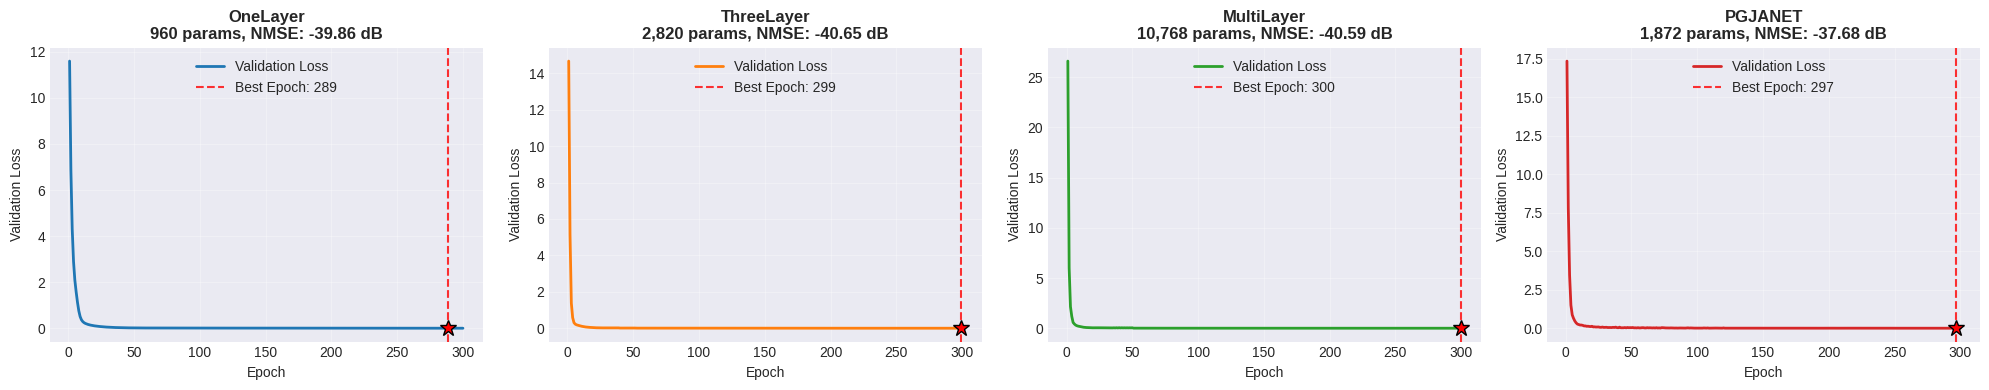

In [ ]:
# Display baseline results
print("\n" + "="*70)
print("BASELINE MODEL COMPARISON")
print("="*70)
print(f"{'Model':<20} {'Parameters':>12} {'NMSE (dB)':>12}")
print("-"*70)
for name, results in baseline_results.items():
    print(f"{name:<20} {results['params']:>12,} {results['nmse']:>12.2f}")
print("="*70)

# Plot baseline training curves
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (name, results) in enumerate(baseline_results.items()):
    ax = axes[idx]
    valid_losses = results['valid_losses']
    best_epoch = results['best_epoch']
    epochs = np.arange(1, len(valid_losses) + 1)
    
    ax.plot(epochs, valid_losses, linewidth=2, color=colors[idx], label='Validation Loss')
    ax.axvline(x=best_epoch, linestyle='--', linewidth=1.5, color='red', alpha=0.8, label=f'Best Epoch: {best_epoch}')
    ax.plot(best_epoch, valid_losses[best_epoch-1], marker='*', markersize=12, color='red', markeredgecolor='black')
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Loss')
    ax.set_title(f'{name}\n{results["params"]:,} params, NMSE: {results["nmse"]:.2f} dB', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Linear/Magnitude Pruning Experiments

Running magnitude-based pruning on all four network architectures.

In [ ]:
# Store pruning experiment results
linear_pruning_results = {}

retrain_epochs = 100

print("\n" + "="*70)
print("LINEAR/MAGNITUDE PRUNING EXPERIMENTS")
print("="*70)


LINEAR/MAGNITUDE PRUNING EXPERIMENTS



Linear Pruning - OneLayerNetwork

Pruning Iteration 1/12
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.5196e-01  Valid Loss=1.3283e-02  LR=1.00e-03
Epoch  20/100  Loss=2.4680e-01  Valid Loss=1.2640e-02  LR=1.00e-03
Epoch  30/100  Loss=2.4419e-01  Valid Loss=1.2283e-02  LR=1.00e-03
Epoch  40/100  Loss=2.4123e-01  Valid Loss=1.2068e-02  LR=1.00e-03
Epoch  50/100  Loss=2.3365e-01  Valid Loss=1.1898e-02  LR=1.00e-03
Epoch  60/100  Loss=2.4042e-01  Valid Loss=1.1804e-02  LR=1.00e-03
Epoch  70/100  Loss=2.2582e-01  Valid Loss=1.1768e-02  LR=1.00e-03
Epoch  80/100  Loss=1.9591e-01  Valid Loss=9.0226e-03  LR=5.00e-04
Epoch  90/100  Loss=1.7298e-01  Valid Loss=8.6014e-03  LR=2.50e-04
Epoch 100/100  Loss=1.7456e-01  Valid Loss=8.5680e-03  LR=2.50e-04

Best model from epoch 93 with validation loss: 8.5633e-03
NMSE: -39.9173 dB

Pruning Iteration 2/12
Pruning 20.0% of remaining weights...
Current pruning: 36.04

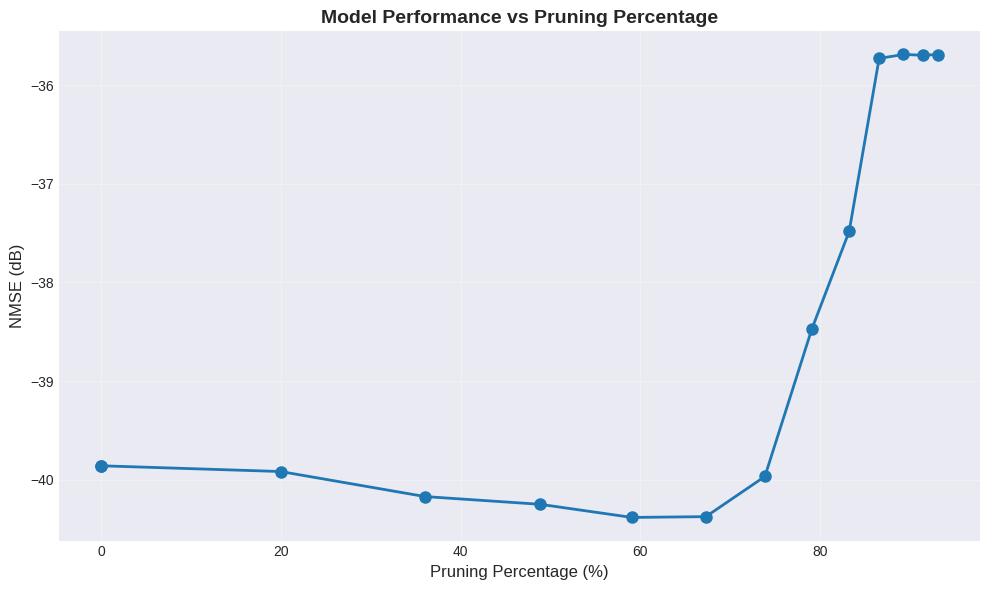

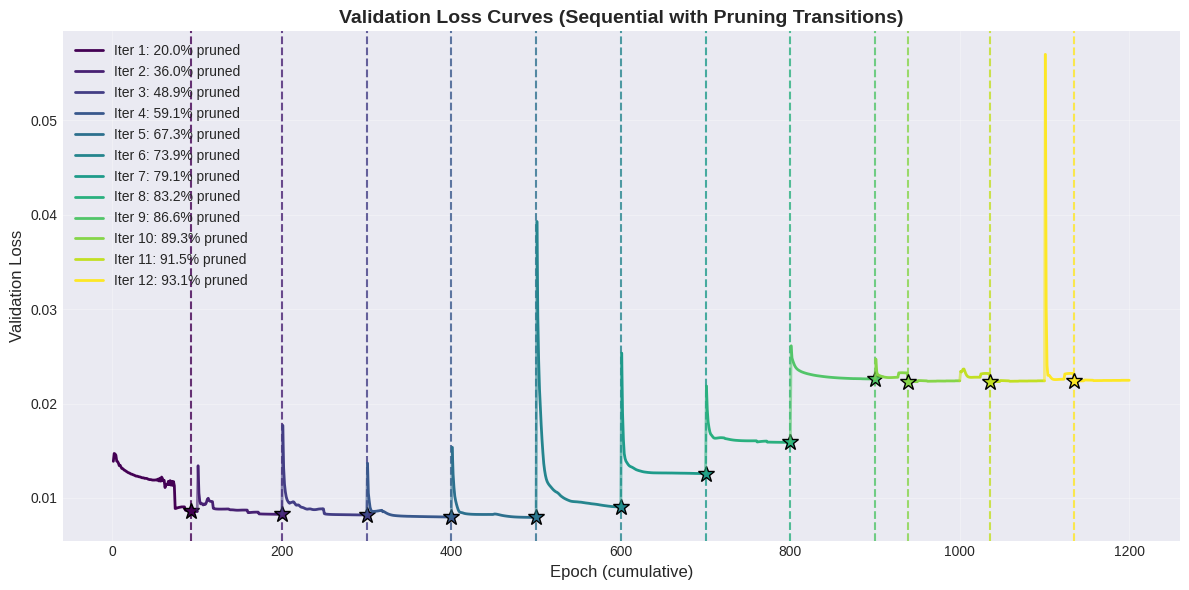

In [ ]:
# 3.1 Linear Pruning - OneLayerNetwork
print("\n" + "="*70)
print("Linear Pruning - OneLayerNetwork")
print("="*70)


exp_linear_one = LinearExperiment(
    nn_model=models['OneLayer'],
    num_prune_iterations=12,
    prune_amount=0.2,
    retrain_epochs=retrain_epochs,
    training_dataset=dataManager.get_training_data(),
    valid_dataset=dataManager.get_validation_data(),
    test_dataset=dataManager.get_test_data()
)

# Run experiment and store results (don't call prune() again later)
initial_nmse = exp_linear_one.original_nn_model.calculate_forward_nmse(exp_linear_one.test_dataset)
prune_pcts, nmse_results, valid_losses, best_epochs, all_valid_losses = exp_linear_one.prune()

linear_pruning_results['OneLayer'] = {
    'prune_pcts': [0.0] + prune_pcts,
    'nmse': [initial_nmse] + nmse_results,
    'valid_losses': all_valid_losses,
    'best_epochs': best_epochs
}

# Show the built-in plots
exp_linear_one.plot_results([0.0] + prune_pcts, [initial_nmse] + nmse_results, initial_nmse)
exp_linear_one.plot_training_curves(all_valid_losses, best_epochs, prune_pcts)


Linear Pruning - ThreeLayerNetwork

Pruning Iteration 1/12
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.7103e-01  Valid Loss=1.8275e-02  LR=1.00e-03
Epoch  20/100  Loss=1.8373e-01  Valid Loss=1.1415e-02  LR=5.00e-04
Epoch  30/100  Loss=1.6287e-01  Valid Loss=7.6983e-03  LR=2.50e-04
Epoch  40/100  Loss=1.6603e-01  Valid Loss=7.8372e-03  LR=2.50e-04
Epoch  50/100  Loss=1.5000e-01  Valid Loss=7.7553e-03  LR=1.25e-04
Epoch  60/100  Loss=1.4278e-01  Valid Loss=7.5195e-03  LR=6.25e-05
Epoch  70/100  Loss=1.4321e-01  Valid Loss=7.4788e-03  LR=6.25e-05
Epoch  80/100  Loss=1.4351e-01  Valid Loss=7.4569e-03  LR=6.25e-05
Epoch  90/100  Loss=1.4347e-01  Valid Loss=7.4411e-03  LR=6.25e-05
Epoch 100/100  Loss=1.4330e-01  Valid Loss=7.4298e-03  LR=6.25e-05

Best model from epoch 100 with validation loss: 7.4298e-03
NMSE: -40.8390 dB

Pruning Iteration 2/12
Pruning 20.0% of remaining weights...
Current pruning: 35

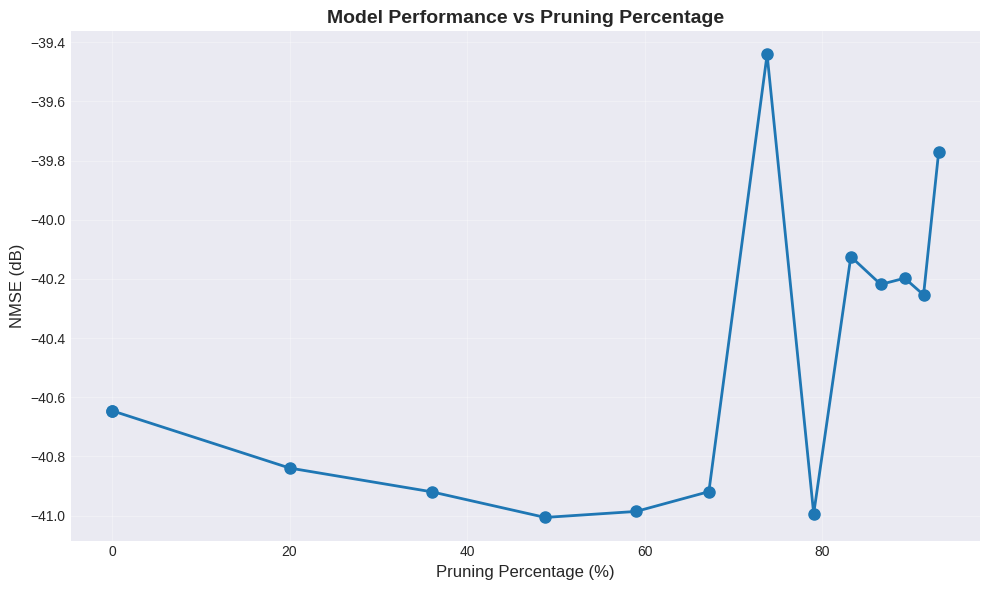

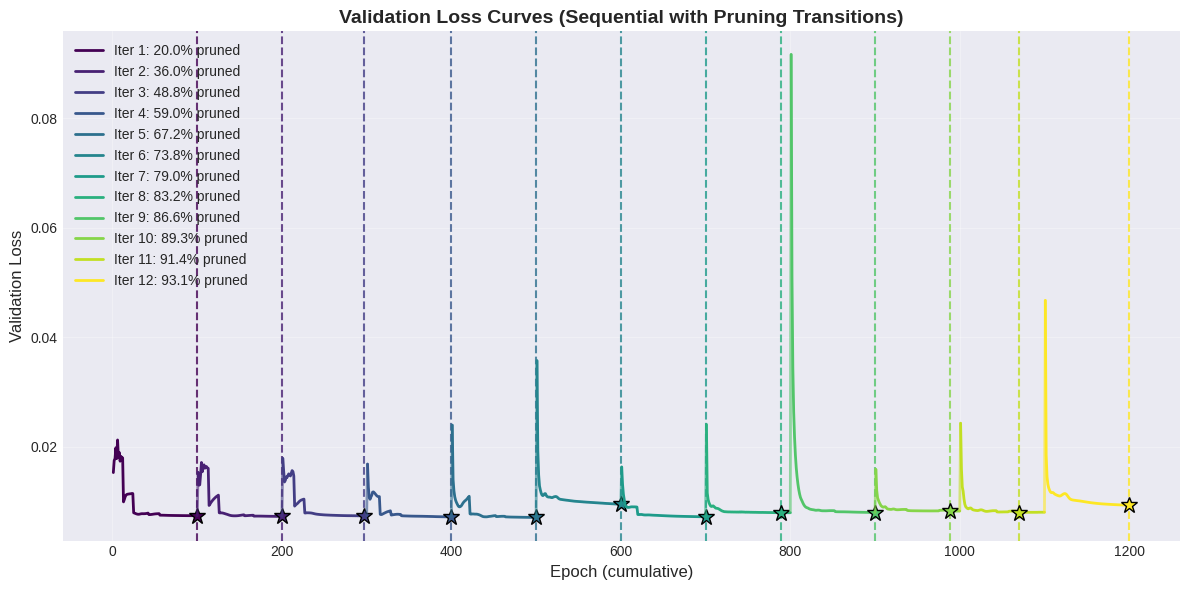

In [ ]:
# 3.2 Linear Pruning - ThreeLayerNetwork
print("\n" + "="*70)
print("Linear Pruning - ThreeLayerNetwork")
print("="*70)

exp_linear_three = LinearExperiment(
    nn_model=models['ThreeLayer'],
    num_prune_iterations=12,
    prune_amount=0.2,
    retrain_epochs=retrain_epochs,
    training_dataset=dataManager.get_training_data(),
    valid_dataset=dataManager.get_validation_data(),
    test_dataset=dataManager.get_test_data()
)

# Run experiment and store results
initial_nmse = exp_linear_three.original_nn_model.calculate_forward_nmse(exp_linear_three.test_dataset)
prune_pcts, nmse_results, valid_losses, best_epochs, all_valid_losses = exp_linear_three.prune()

linear_pruning_results['ThreeLayer'] = {
    'prune_pcts': [0.0] + prune_pcts,
    'nmse': [initial_nmse] + nmse_results,
    'valid_losses': all_valid_losses,
    'best_epochs': best_epochs
}

# Show the built-in plots
exp_linear_three.plot_results([0.0] + prune_pcts, [initial_nmse] + nmse_results, initial_nmse)
exp_linear_three.plot_training_curves(all_valid_losses, best_epochs, prune_pcts)


Linear Pruning - MultiLayerNetwork

Pruning Iteration 1/12
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=7.9602e-01  Valid Loss=3.2337e-02  LR=1.00e-03
Epoch  20/100  Loss=1.8740e-01  Valid Loss=1.0868e-02  LR=5.00e-04
Epoch  30/100  Loss=2.0591e-01  Valid Loss=1.2216e-02  LR=2.50e-04
Epoch  40/100  Loss=1.7554e-01  Valid Loss=8.7260e-03  LR=2.50e-04
Epoch  50/100  Loss=1.5999e-01  Valid Loss=8.2506e-03  LR=1.25e-04
Epoch  60/100  Loss=1.4667e-01  Valid Loss=7.3396e-03  LR=6.25e-05
Epoch  70/100  Loss=1.4319e-01  Valid Loss=7.3587e-03  LR=3.13e-05
Epoch  80/100  Loss=1.4291e-01  Valid Loss=7.2928e-03  LR=3.13e-05
Epoch  90/100  Loss=1.4287e-01  Valid Loss=7.2739e-03  LR=3.13e-05
Epoch 100/100  Loss=1.4269e-01  Valid Loss=7.2615e-03  LR=3.13e-05

Best model from epoch 100 with validation loss: 7.2615e-03
NMSE: -40.7622 dB

Pruning Iteration 2/12
Pruning 20.0% of remaining weights...
Current pruning: 36

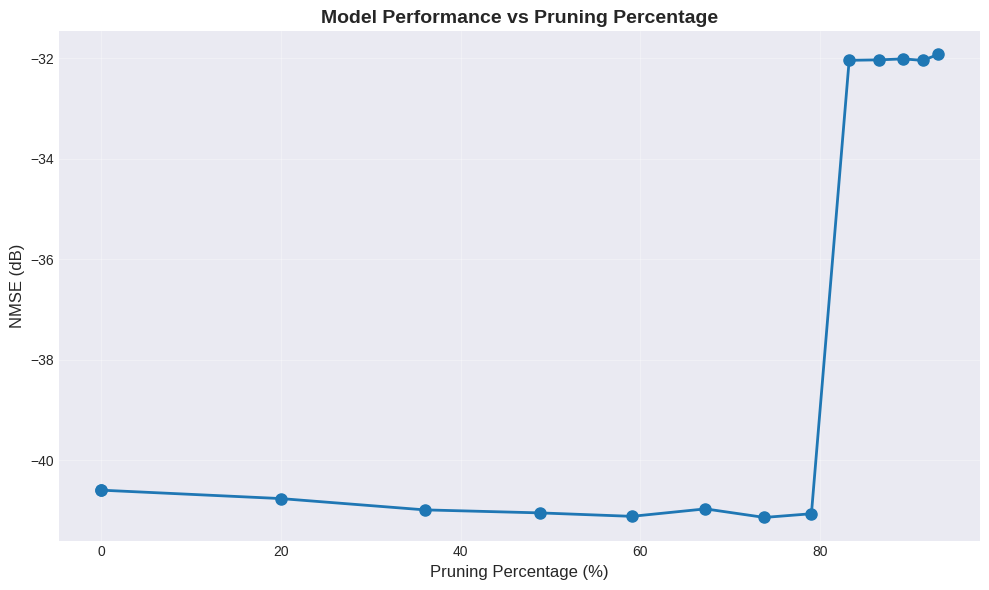

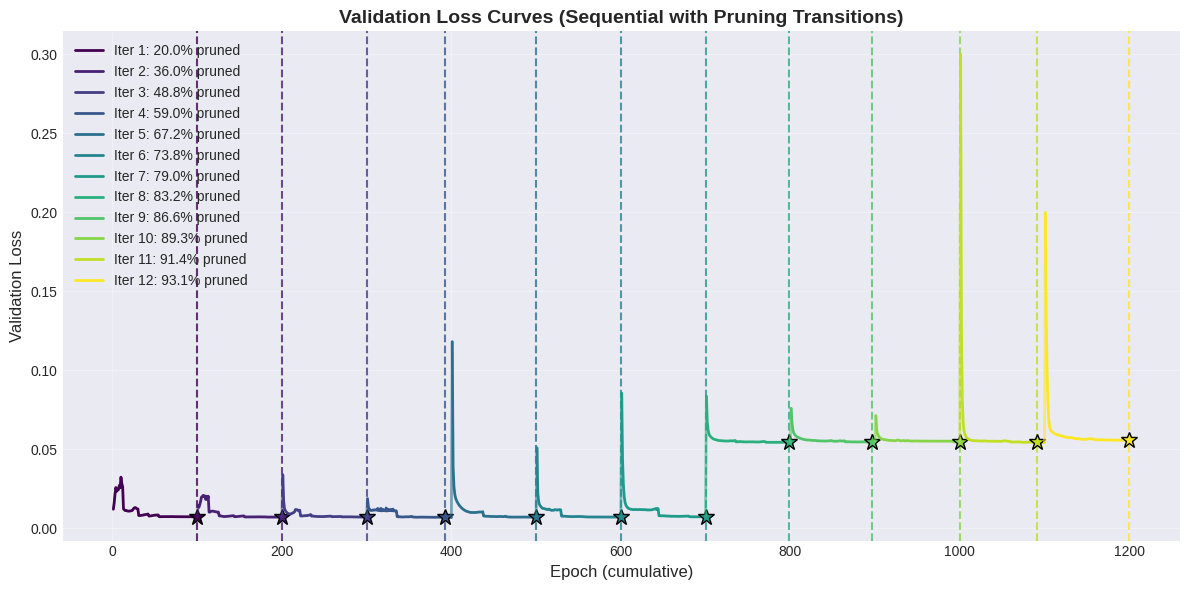

In [ ]:
# 3.3 Linear Pruning - MultiLayerNetwork
print("\n" + "="*70)
print("Linear Pruning - MultiLayerNetwork")
print("="*70)

exp_linear_multi = LinearExperiment(
    nn_model=models['MultiLayer'],
    num_prune_iterations=12,
    prune_amount=0.2,
    retrain_epochs=retrain_epochs,
    training_dataset=dataManager.get_training_data(),
    valid_dataset=dataManager.get_validation_data(),
    test_dataset=dataManager.get_test_data()
)

# Run experiment and store results
initial_nmse = exp_linear_multi.original_nn_model.calculate_forward_nmse(exp_linear_multi.test_dataset)
prune_pcts, nmse_results, valid_losses, best_epochs, all_valid_losses = exp_linear_multi.prune()

linear_pruning_results['MultiLayer'] = {
    'prune_pcts': [0.0] + prune_pcts,
    'nmse': [initial_nmse] + nmse_results,
    'valid_losses': all_valid_losses,
    'best_epochs': best_epochs
}

# Show the built-in plots
exp_linear_multi.plot_results([0.0] + prune_pcts, [initial_nmse] + nmse_results, initial_nmse)
exp_linear_multi.plot_training_curves(all_valid_losses, best_epochs, prune_pcts)


Linear Pruning - PGJANET

Pruning Iteration 1/12
Pruning 20.0% of remaining weights...
Current pruning: 19.98% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=3.6777e-01  Valid Loss=1.8214e-02  LR=1.00e-03
Epoch  20/100  Loss=3.6960e-01  Valid Loss=4.4045e-02  LR=1.00e-03
Epoch  30/100  Loss=2.8698e-01  Valid Loss=1.3033e-02  LR=5.00e-04
Epoch  40/100  Loss=2.9149e-01  Valid Loss=1.6037e-02  LR=5.00e-04
Epoch  50/100  Loss=2.6762e-01  Valid Loss=1.3849e-02  LR=2.50e-04
Epoch  60/100  Loss=2.6744e-01  Valid Loss=1.3508e-02  LR=1.25e-04
Epoch  70/100  Loss=2.5419e-01  Valid Loss=1.2544e-02  LR=1.25e-04
Epoch  80/100  Loss=2.4930e-01  Valid Loss=1.2067e-02  LR=6.25e-05
Epoch  90/100  Loss=2.4765e-01  Valid Loss=1.1725e-02  LR=6.25e-05
Epoch 100/100  Loss=2.4571e-01  Valid Loss=1.1838e-02  LR=6.25e-05

Best model from epoch 90 with validation loss: 1.1725e-02
NMSE: -38.2552 dB

Pruning Iteration 2/12
Pruning 20.0% of remaining weights...
Current pruning: 36.00% of wei

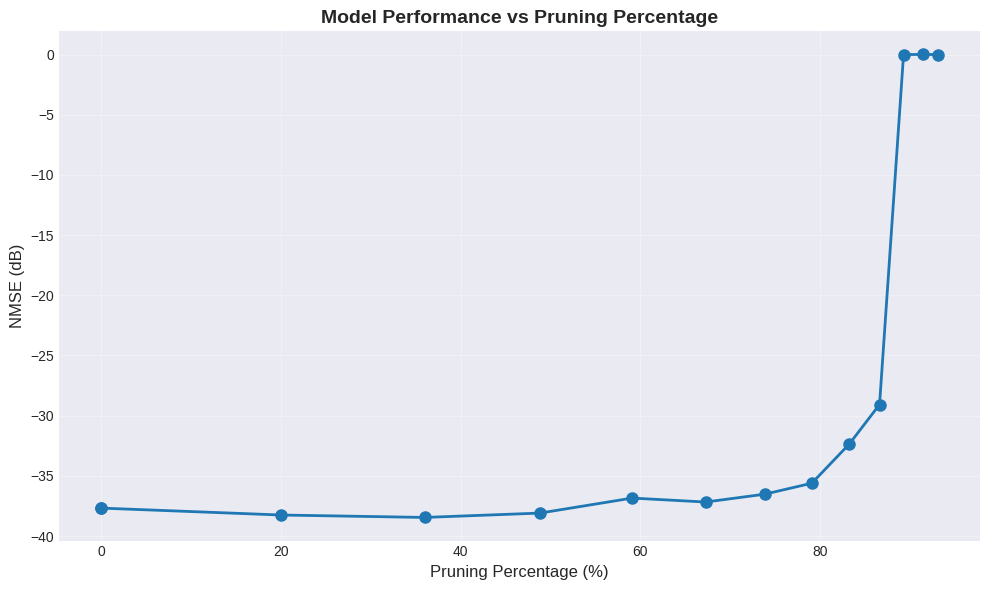

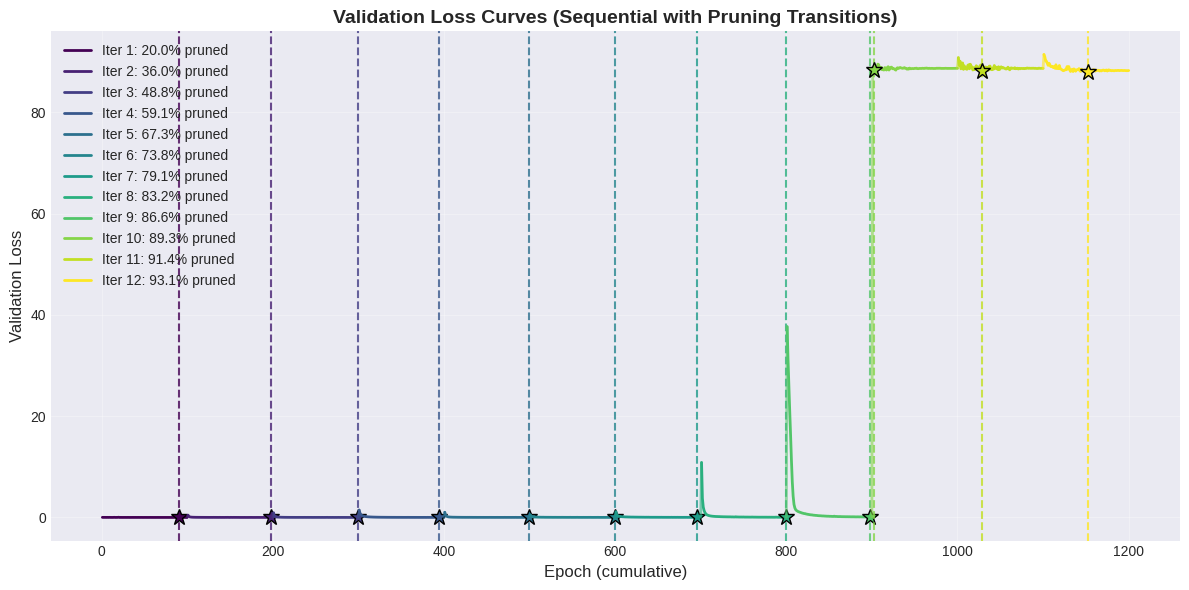

In [ ]:
# 3.4 Linear Pruning - PGJANET
print("\n" + "="*70)
print("Linear Pruning - PGJANET")
print("="*70)

exp_linear_pgjanet = LinearExperiment(
    nn_model=models['PGJANET'],
    num_prune_iterations=12,
    prune_amount=0.2,
    retrain_epochs=retrain_epochs,
    training_dataset=dataManager.get_training_data(),
    valid_dataset=dataManager.get_validation_data(),
    test_dataset=dataManager.get_test_data()
)

# Run experiment and store results
initial_nmse = exp_linear_pgjanet.original_nn_model.calculate_forward_nmse(exp_linear_pgjanet.test_dataset)
prune_pcts, nmse_results, valid_losses, best_epochs, all_valid_losses = exp_linear_pgjanet.prune()

linear_pruning_results['PGJANET'] = {
    'prune_pcts': [0.0] + prune_pcts,
    'nmse': [initial_nmse] + nmse_results,
    'valid_losses': all_valid_losses,
    'best_epochs': best_epochs
}

# Show the built-in plots
exp_linear_pgjanet.plot_results([0.0] + prune_pcts, [initial_nmse] + nmse_results, initial_nmse)
exp_linear_pgjanet.plot_training_curves(all_valid_losses, best_epochs, prune_pcts)

## 4. Node Pruning Experiments

Running node-based pruning on all three network architectures.

In [ ]:
# Store node pruning experiment results
node_pruning_results = {}

print("\n" + "="*70)
print("NODE PRUNING EXPERIMENTS")
print("="*70)


NODE PRUNING EXPERIMENTS



Node Pruning - OneLayerNetwork

Pruning Iteration 1/12
Pruning weakest 20.0% of hidden nodes...
Pruned 2 hidden nodes
Current pruning: 16.25% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.6245e-01  Valid Loss=1.4089e-02  LR=1.00e-03
Epoch  20/100  Loss=2.1727e-01  Valid Loss=9.1856e-03  LR=5.00e-04
Epoch  30/100  Loss=2.0787e-01  Valid Loss=9.1622e-03  LR=5.00e-04
Epoch  40/100  Loss=1.8688e-01  Valid Loss=8.7825e-03  LR=2.50e-04
Epoch  50/100  Loss=1.8703e-01  Valid Loss=8.6502e-03  LR=2.50e-04
Epoch  60/100  Loss=1.8412e-01  Valid Loss=8.4407e-03  LR=2.50e-04
Epoch  70/100  Loss=1.8044e-01  Valid Loss=8.2873e-03  LR=2.50e-04
Epoch  80/100  Loss=1.7687e-01  Valid Loss=8.1817e-03  LR=2.50e-04
Epoch  90/100  Loss=1.7389e-01  Valid Loss=8.0650e-03  LR=2.50e-04
Epoch 100/100  Loss=1.7170e-01  Valid Loss=7.9616e-03  LR=2.50e-04

Best model from epoch 100 with validation loss: 7.9616e-03
NMSE: -40.3126 dB

Pruning Iteration 2/12
Pruning weakest 20.0% of hidden node

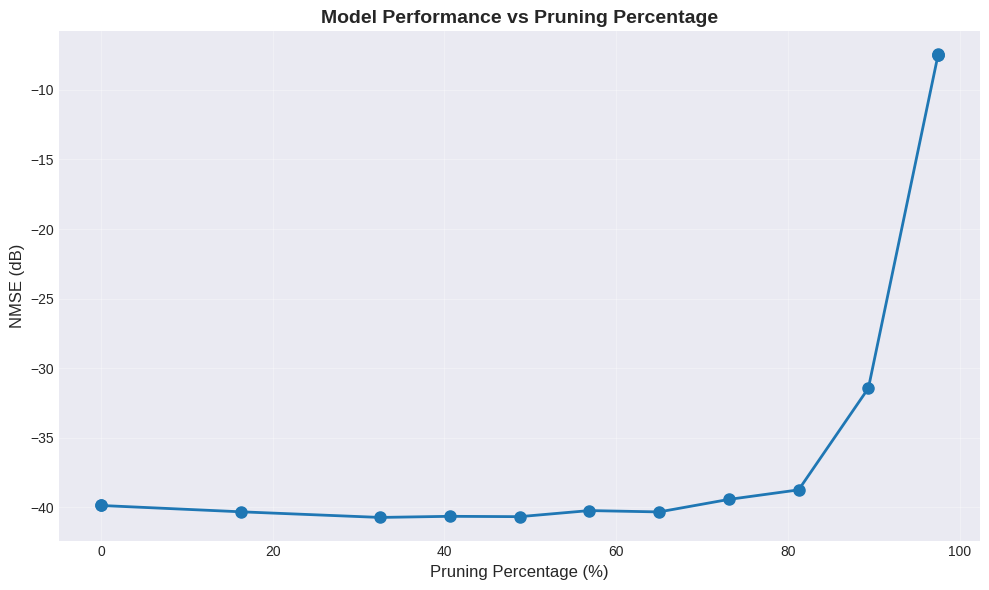

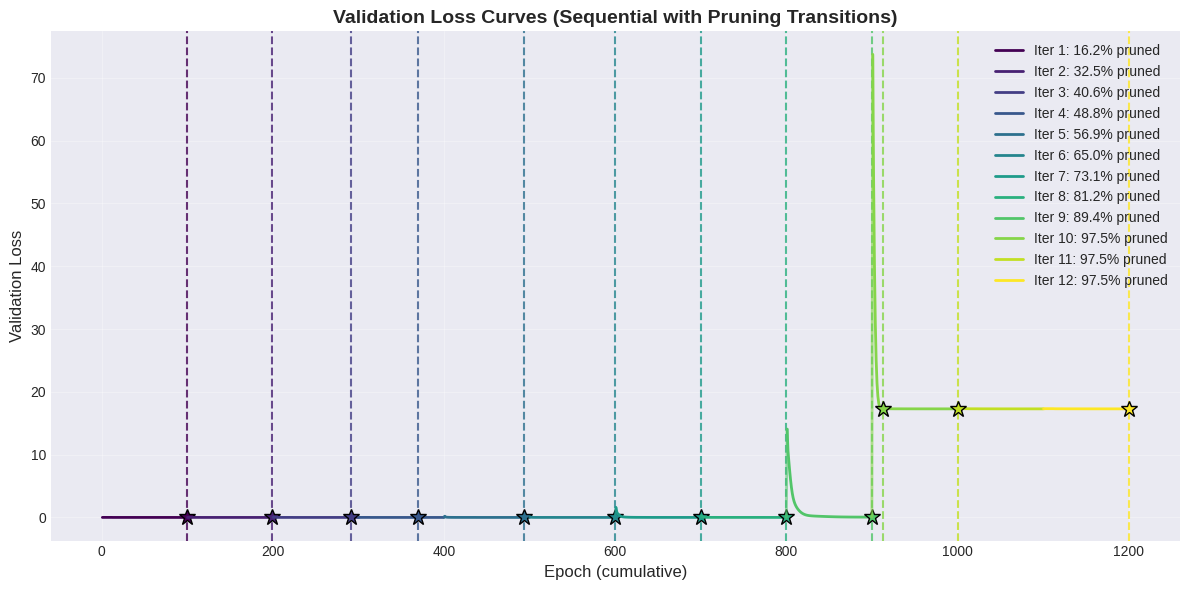

In [ ]:
# 4.1 Node Pruning - OneLayerNetwork
print("\n" + "="*70)
print("Node Pruning - OneLayerNetwork")
print("="*70)

exp_node_one = NodePruningExperiment(
    nn_model=models['OneLayer'],
    num_prune_iterations=12,
    prune_amount=0.2,
    retrain_epochs=retrain_epochs,
    training_dataset=dataManager.get_training_data(),
    valid_dataset=dataManager.get_validation_data(),
    test_dataset=dataManager.get_test_data()
)

# Run experiment and store results
initial_nmse = exp_node_one.original_nn_model.calculate_forward_nmse(exp_node_one.test_dataset)
prune_pcts, nmse_results, valid_losses, best_epochs, all_valid_losses = exp_node_one.prune()

node_pruning_results['OneLayer'] = {
    'prune_pcts': [0.0] + prune_pcts,
    'nmse': [initial_nmse] + nmse_results,
    'valid_losses': all_valid_losses,
    'best_epochs': best_epochs
}

# Show the built-in plots
exp_node_one.plot_results([0.0] + prune_pcts, [initial_nmse] + nmse_results, initial_nmse)
exp_node_one.plot_training_curves(all_valid_losses, best_epochs, prune_pcts)


Node Pruning - ThreeLayerNetwork

Pruning Iteration 1/12
Pruning weakest 20.0% of hidden nodes...
Pruned 9 hidden nodes
Current pruning: 9.57% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.1360e-01  Valid Loss=1.0287e-02  LR=1.00e-03
Epoch  20/100  Loss=2.1053e-01  Valid Loss=8.5964e-03  LR=5.00e-04
Epoch  30/100  Loss=1.8309e-01  Valid Loss=9.4102e-03  LR=5.00e-04
Epoch  40/100  Loss=1.6748e-01  Valid Loss=8.4842e-03  LR=2.50e-04
Epoch  50/100  Loss=1.5315e-01  Valid Loss=8.1273e-03  LR=1.25e-04
Epoch  60/100  Loss=1.5502e-01  Valid Loss=8.0689e-03  LR=1.25e-04
Epoch  70/100  Loss=1.5494e-01  Valid Loss=8.0083e-03  LR=1.25e-04
Epoch  80/100  Loss=1.5376e-01  Valid Loss=7.9514e-03  LR=1.25e-04
Epoch  90/100  Loss=1.5286e-01  Valid Loss=7.8918e-03  LR=1.25e-04
Epoch 100/100  Loss=1.5207e-01  Valid Loss=7.8075e-03  LR=1.25e-04

Best model from epoch 100 with validation loss: 7.8075e-03
NMSE: -40.6993 dB

Pruning Iteration 2/12
Pruning weakest 20.0% of hidden nod

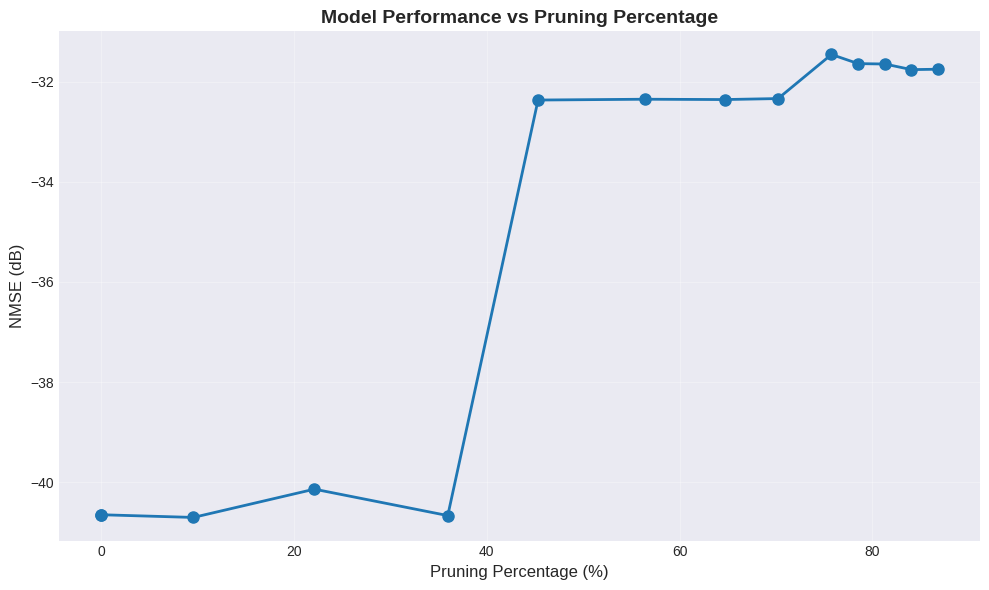

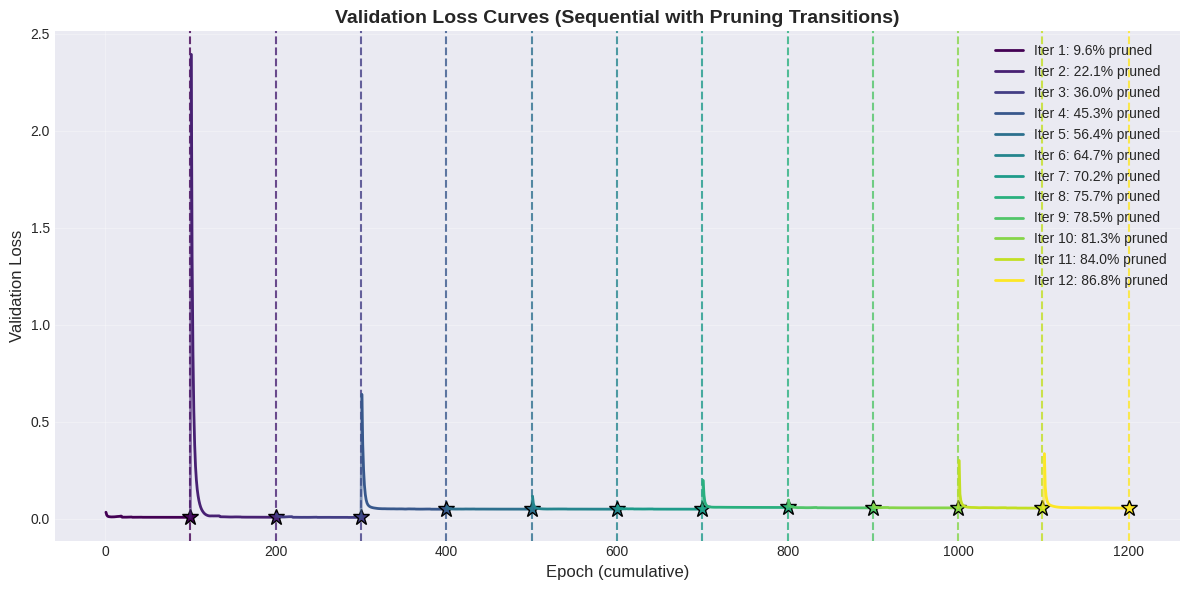

In [ ]:
# 4.2 Node Pruning - ThreeLayerNetwork
print("\n" + "="*70)
print("Node Pruning - ThreeLayerNetwork")
print("="*70)

exp_node_three = NodePruningExperiment(
    nn_model=models['ThreeLayer'],
    num_prune_iterations=12,
    prune_amount=0.2,
    retrain_epochs=retrain_epochs,
    training_dataset=dataManager.get_training_data(),
    valid_dataset=dataManager.get_validation_data(),
    test_dataset=dataManager.get_test_data()
)

# Run experiment and store results
initial_nmse = exp_node_three.original_nn_model.calculate_forward_nmse(exp_node_three.test_dataset)
prune_pcts, nmse_results, valid_losses, best_epochs, all_valid_losses = exp_node_three.prune()

node_pruning_results['ThreeLayer'] = {
    'prune_pcts': [0.0] + prune_pcts,
    'nmse': [initial_nmse] + nmse_results,
    'valid_losses': all_valid_losses,
    'best_epochs': best_epochs
}

# Show the built-in plots
exp_node_three.plot_results([0.0] + prune_pcts, [initial_nmse] + nmse_results, initial_nmse)
exp_node_three.plot_training_curves(all_valid_losses, best_epochs, prune_pcts)

In [ ]:
# 4.3 Node Pruning - MultiLayerNetwork
print("\n" + "="*70)
print("Node Pruning - MultiLayerNetwork")
print("="*70)

exp_node_multi = NodePruningExperiment(
    nn_model=models['MultiLayer'],
    num_prune_iterations=12,
    prune_amount=0.2,
    retrain_epochs=retrain_epochs,
    training_dataset=dataManager.get_training_data(),
    valid_dataset=dataManager.get_validation_data(),
    test_dataset=dataManager.get_test_data()
)

# Run experiment and store results
initial_nmse = exp_node_multi.original_nn_model.calculate_forward_nmse(exp_node_multi.test_dataset)
prune_pcts, nmse_results, valid_losses, best_epochs, all_valid_losses = exp_node_multi.prune()

node_pruning_results['MultiLayer'] = {
    'prune_pcts': [0.0] + prune_pcts,
    'nmse': [initial_nmse] + nmse_results,
    'valid_losses': all_valid_losses,
    'best_epochs': best_epochs
}

# Show the built-in plots
exp_node_multi.plot_results([0.0] + prune_pcts, [initial_nmse] + nmse_results, initial_nmse)
exp_node_multi.plot_training_curves(all_valid_losses, best_epochs, prune_pcts)


Node Pruning - MultiLayerNetwork

Pruning Iteration 1/12
Pruning weakest 20.0% of hidden nodes...
Pruned 43 hidden nodes (with forward connections)
Current pruning: 26.80% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=3.3749e-01  Valid Loss=1.8831e-02  LR=1.00e-03
Epoch  20/100  Loss=2.9340e-01  Valid Loss=2.0256e-02  LR=1.00e-03
Epoch  30/100  Loss=2.1687e-01  Valid Loss=1.2871e-02  LR=5.00e-04
Epoch  40/100  Loss=2.2536e-01  Valid Loss=1.3964e-02  LR=5.00e-04
Epoch  50/100  Loss=1.9140e-01  Valid Loss=1.0948e-02  LR=2.50e-04
Epoch  60/100  Loss=1.6826e-01  Valid Loss=8.3512e-03  LR=1.25e-04
Epoch  70/100  Loss=1.7300e-01  Valid Loss=8.1566e-03  LR=1.25e-04
Epoch  80/100  Loss=1.7361e-01  Valid Loss=8.2388e-03  LR=1.25e-04
Epoch  90/100  Loss=1.5198e-01  Valid Loss=7.6713e-03  LR=6.25e-05
Epoch 100/100  Loss=1.4617e-01  Valid Loss=7.7248e-03  LR=3.13e-05

Best model from epoch 88 with validation loss: 7.6695e-03
NMSE: -40.6966 dB

Pruning Iteration 2/12
Pruning

KeyboardInterrupt: 

## 5. Comprehensive Analysis and Visualization

Now we'll create detailed comparisons across all experiments.

In [ ]:
# All pruning results are now stored in:
# - linear_pruning_results[model_name] = {'prune_pcts': [...], 'nmse': [...], 'valid_losses': [...], 'best_epochs': [...]}
# - node_pruning_results[model_name] = {'prune_pcts': [...], 'nmse': [...], 'valid_losses': [...], 'best_epochs': [...]}

print("All pruning experiments completed!")
print("Results are stored and ready for visualization.")

All pruning experiments completed!
Results are stored and ready for visualization.


### 5.1 NMSE vs Pruning Percentage - All Models

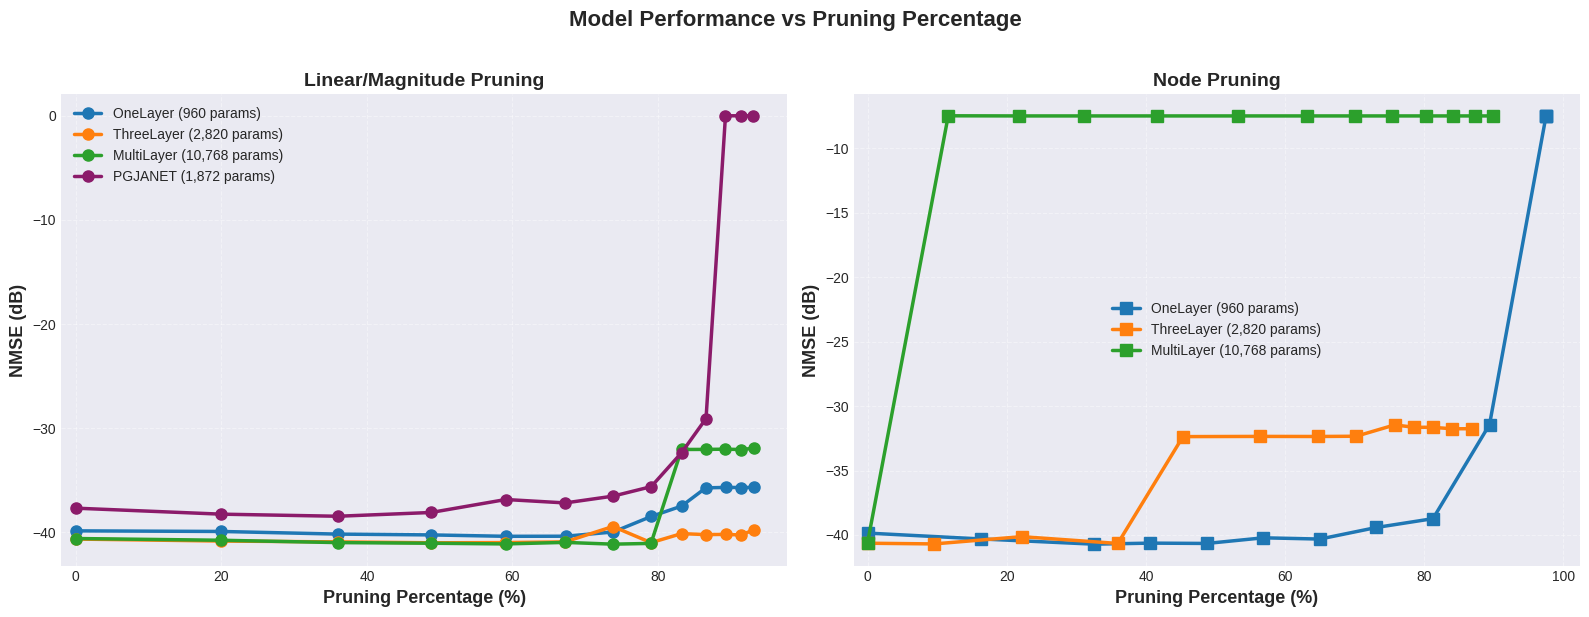

In [ ]:
# Plot NMSE vs Pruning Percentage for Linear Pruning
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color scheme for models
model_colors = {
    'OneLayer': '#1f77b4',
    'ThreeLayer': '#ff7f0e',
    'MultiLayer': '#2ca02c',
    'PGJANET' : "#8b1b6a"
}

# Left plot: Linear Pruning
ax_linear = axes[0]
for model_name, results in linear_pruning_results.items():
    prune_pcts_full = results['prune_pcts']
    nmse_results_full = results['nmse']
    
    ax_linear.plot(prune_pcts_full, nmse_results_full, 
                   marker='o', linewidth=2.5, markersize=8,
                   color=model_colors[model_name],
                   label=f'{model_name} ({baseline_results[model_name]["params"]:,} params)')

ax_linear.set_xlabel('Pruning Percentage (%)', fontsize=13, fontweight='bold')
ax_linear.set_ylabel('NMSE (dB)', fontsize=13, fontweight='bold')
ax_linear.set_title('Linear/Magnitude Pruning', fontsize=14, fontweight='bold')
ax_linear.legend(fontsize=10, loc='best')
ax_linear.grid(True, alpha=0.4, linestyle='--')
ax_linear.set_xlim(left=-2)

# Right plot: Node Pruning
ax_node = axes[1]
for model_name, results in node_pruning_results.items():
    prune_pcts_full = results['prune_pcts']
    nmse_results_full = results['nmse']
    
    ax_node.plot(prune_pcts_full, nmse_results_full,
                 marker='s', linewidth=2.5, markersize=8,
                 color=model_colors[model_name],
                 label=f'{model_name} ({baseline_results[model_name]["params"]:,} params)')

ax_node.set_xlabel('Pruning Percentage (%)', fontsize=13, fontweight='bold')
ax_node.set_ylabel('NMSE (dB)', fontsize=13, fontweight='bold')
ax_node.set_title('Node Pruning', fontsize=14, fontweight='bold')
ax_node.legend(fontsize=10, loc='best')
ax_node.grid(True, alpha=0.4, linestyle='--')
ax_node.set_xlim(left=-2)

plt.suptitle('Model Performance vs Pruning Percentage', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Combined Comparison - NMSE vs Pruning Percentage

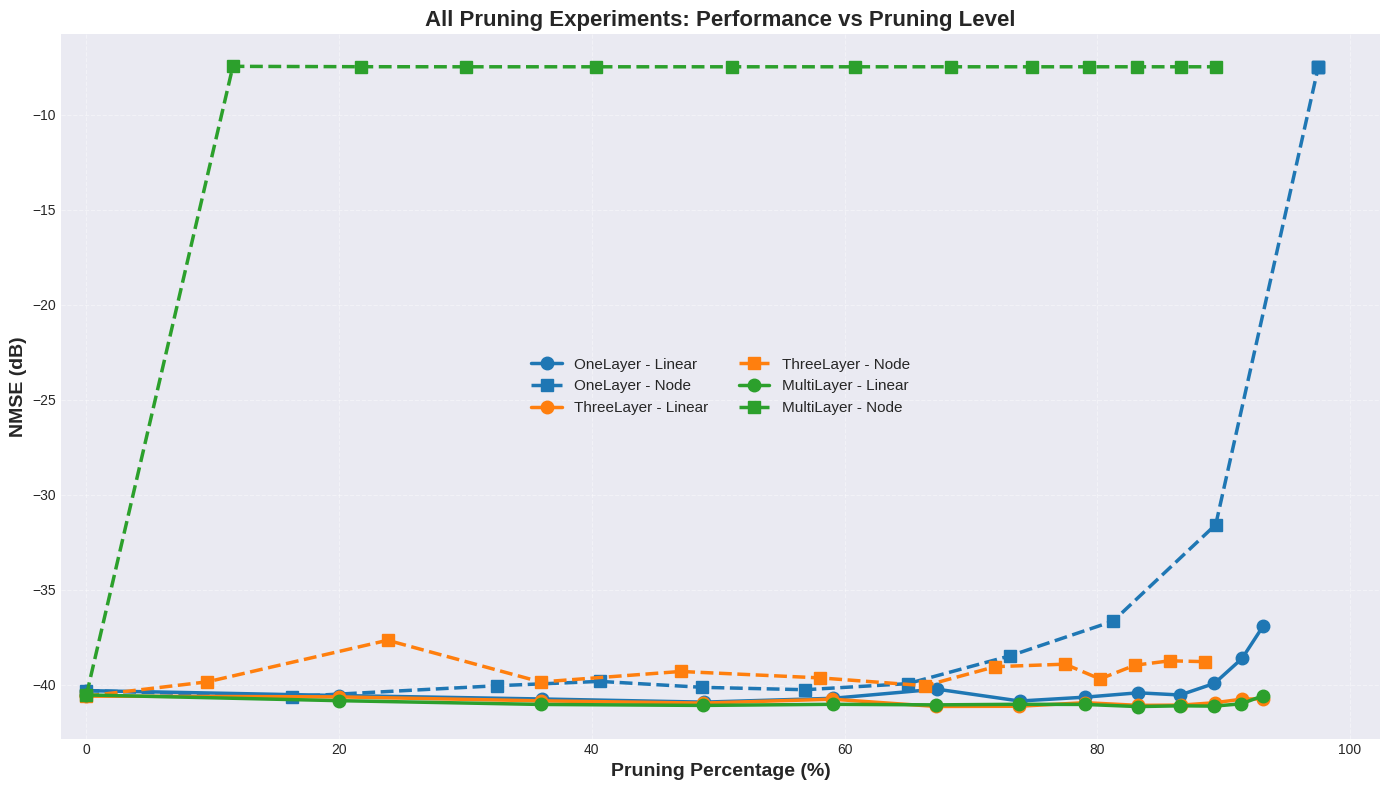

In [ ]:
# Single plot comparing all 6 combinations
fig, ax = plt.subplots(figsize=(14, 8))

# Line styles for pruning methods
pruning_styles = {
    'Linear': {'linestyle': '-', 'marker': 'o'},
    'Node': {'linestyle': '--', 'marker': 's'}
}

for model_name in ['OneLayer', 'ThreeLayer', 'MultiLayer']:
    # Linear pruning - use stored results
    linear_results = linear_pruning_results[model_name]
    prune_pcts_l_full = linear_results['prune_pcts']
    nmse_l_full = linear_results['nmse']
    
    ax.plot(prune_pcts_l_full, nmse_l_full,
            color=model_colors[model_name],
            linewidth=2.5, markersize=9,
            linestyle=pruning_styles['Linear']['linestyle'],
            marker=pruning_styles['Linear']['marker'],
            label=f'{model_name} - Linear')
    
    # Node pruning - use stored results
    node_results = node_pruning_results[model_name]
    prune_pcts_n_full = node_results['prune_pcts']
    nmse_n_full = node_results['nmse']
    
    ax.plot(prune_pcts_n_full, nmse_n_full,
            color=model_colors[model_name],
            linewidth=2.5, markersize=9,
            linestyle=pruning_styles['Node']['linestyle'],
            marker=pruning_styles['Node']['marker'],
            label=f'{model_name} - Node')

ax.set_xlabel('Pruning Percentage (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('NMSE (dB)', fontsize=14, fontweight='bold')
ax.set_title('All Pruning Experiments: Performance vs Pruning Level', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='best', ncol=2)
ax.grid(True, alpha=0.4, linestyle='--')
ax.set_xlim(left=-2)

plt.tight_layout()
plt.show()

### 5.3 Parameter Efficiency Analysis

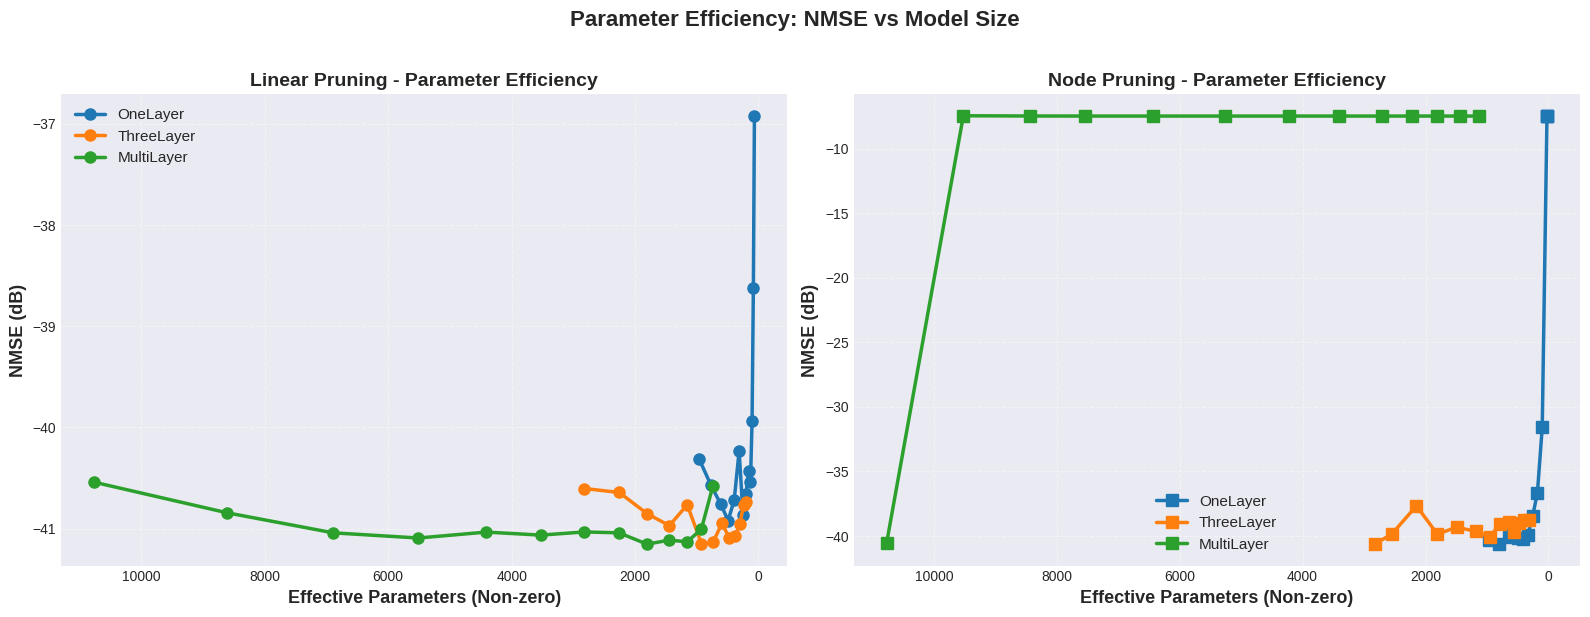

In [ ]:
# Create parameter efficiency plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate effective parameters at each pruning level
def calc_effective_params(base_params, prune_pct):
    """Calculate number of non-zero parameters"""
    return int(base_params * (1 - prune_pct / 100))

# Left plot: Linear Pruning - NMSE vs Effective Parameters
ax_linear = axes[0]
for model_name, results in linear_pruning_results.items():
    base_params = baseline_results[model_name]['params']
    prune_pcts_full = results['prune_pcts']
    nmse_results_full = results['nmse']
    
    effective_params = [calc_effective_params(base_params, pct) for pct in prune_pcts_full]
    
    ax_linear.plot(effective_params, nmse_results_full,
                   marker='o', linewidth=2.5, markersize=8,
                   color=model_colors[model_name],
                   label=model_name)

ax_linear.set_xlabel('Effective Parameters (Non-zero)', fontsize=13, fontweight='bold')
ax_linear.set_ylabel('NMSE (dB)', fontsize=13, fontweight='bold')
ax_linear.set_title('Linear Pruning - Parameter Efficiency', fontsize=14, fontweight='bold')
ax_linear.legend(fontsize=11)
ax_linear.grid(True, alpha=0.4, linestyle='--')
ax_linear.invert_xaxis()  # Fewer params on right

# Right plot: Node Pruning - NMSE vs Effective Parameters
ax_node = axes[1]
for model_name, results in node_pruning_results.items():
    base_params = baseline_results[model_name]['params']
    prune_pcts_full = results['prune_pcts']
    nmse_results_full = results['nmse']
    
    effective_params = [calc_effective_params(base_params, pct) for pct in prune_pcts_full]
    
    ax_node.plot(effective_params, nmse_results_full,
                 marker='s', linewidth=2.5, markersize=8,
                 color=model_colors[model_name],
                 label=model_name)

ax_node.set_xlabel('Effective Parameters (Non-zero)', fontsize=13, fontweight='bold')
ax_node.set_ylabel('NMSE (dB)', fontsize=13, fontweight='bold')
ax_node.set_title('Node Pruning - Parameter Efficiency', fontsize=14, fontweight='bold')
ax_node.legend(fontsize=11)
ax_node.grid(True, alpha=0.4, linestyle='--')
ax_node.invert_xaxis()  # Fewer params on right

plt.suptitle('Parameter Efficiency: NMSE vs Model Size', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Performance Retention at Key Pruning Levels

In [ ]:
# Create performance retention table and visualization
pruning_levels = [0, 50, 75, 90]

def get_nmse_at_pruning_level(results_dict, target_pct):
    """Interpolate NMSE at a given pruning percentage"""
    prune_pcts_full = np.array(results_dict['prune_pcts'])
    nmse_results_full = np.array(results_dict['nmse'])
    
    if target_pct <= prune_pcts_full.max():
        return np.interp(target_pct, prune_pcts_full, nmse_results_full)
    else:
        return np.nan

# Build retention data
retention_data = []

for model_name in ['OneLayer', 'ThreeLayer', 'MultiLayer']:
    baseline_nmse = baseline_results[model_name]['nmse']
    base_params = baseline_results[model_name]['params']
    
    for pruning_level in pruning_levels:
        # Linear pruning
        nmse_linear = get_nmse_at_pruning_level(
            linear_pruning_results[model_name],
            pruning_level
        )
        degradation_linear = nmse_linear - baseline_nmse if not np.isnan(nmse_linear) else np.nan
        
        # Node pruning
        nmse_node = get_nmse_at_pruning_level(
            node_pruning_results[model_name],
            pruning_level
        )
        degradation_node = nmse_node - baseline_nmse if not np.isnan(nmse_node) else np.nan
        
        retention_data.append({
            'Model': model_name,
            'Pruning Level (%)': pruning_level,
            'Effective Params': calc_effective_params(base_params, pruning_level),
            'Linear NMSE (dB)': nmse_linear,
            'Linear Degradation (dB)': degradation_linear,
            'Node NMSE (dB)': nmse_node,
            'Node Degradation (dB)': degradation_node
        })

retention_df = pd.DataFrame(retention_data)

print("\n" + "="*100)
print("PERFORMANCE RETENTION AT KEY PRUNING LEVELS")
print("="*100)
print(retention_df.to_string(index=False))
print("="*100)


PERFORMANCE RETENTION AT KEY PRUNING LEVELS
     Model  Pruning Level (%)  Effective Params  Linear NMSE (dB)  Linear Degradation (dB)  Node NMSE (dB)  Node Degradation (dB)
  OneLayer                  0               960        -40.312786                 0.000000      -40.312786               0.000000
  OneLayer                 50               480        -40.897059                -0.584273      -40.160219               0.152567
  OneLayer                 75               240        -40.816174                -0.503388      -38.057140               2.255645
  OneLayer                 90                95        -39.495205                 0.817581      -29.721128              10.591658
ThreeLayer                  0              2820        -40.603229                 0.000000      -40.603229               0.000000
ThreeLayer                 50              1410        -40.946016                -0.342787      -39.396746               1.206484
ThreeLayer                 75               7

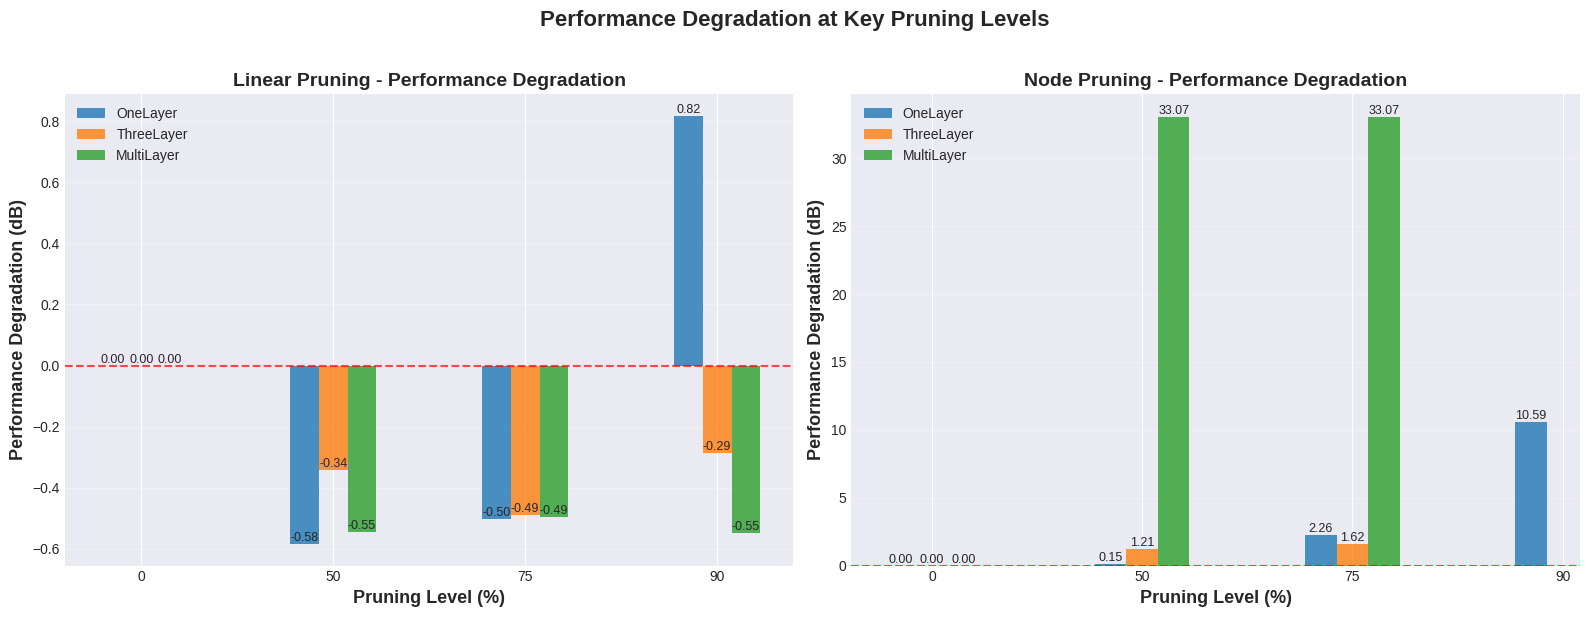

In [ ]:
# Visualize performance degradation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for plotting
models_list = ['OneLayer', 'ThreeLayer', 'MultiLayer']
x = np.arange(len(pruning_levels))
width = 0.15

# Left plot: Linear Pruning Degradation
ax_linear = axes[0]
for i, model_name in enumerate(models_list):
    model_data = retention_df[retention_df['Model'] == model_name]
    degradations = model_data['Linear Degradation (dB)'].values
    
    offset = (i - 1) * width
    bars = ax_linear.bar(x + offset, degradations, width,
                         label=model_name, color=model_colors[model_name], alpha=0.8)
    
    # Add value labels on bars
    for bar, val in zip(bars, degradations):
        if not np.isnan(val):
            height = bar.get_height()
            ax_linear.text(bar.get_x() + bar.get_width()/2., height,
                          f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax_linear.set_xlabel('Pruning Level (%)', fontsize=13, fontweight='bold')
ax_linear.set_ylabel('Performance Degradation (dB)', fontsize=13, fontweight='bold')
ax_linear.set_title('Linear Pruning - Performance Degradation', fontsize=14, fontweight='bold')
ax_linear.set_xticks(x)
ax_linear.set_xticklabels(pruning_levels)
ax_linear.legend()
ax_linear.grid(True, alpha=0.3, axis='y')
ax_linear.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Right plot: Node Pruning Degradation
ax_node = axes[1]
for i, model_name in enumerate(models_list):
    model_data = retention_df[retention_df['Model'] == model_name]
    degradations = model_data['Node Degradation (dB)'].values
    
    offset = (i - 1) * width
    bars = ax_node.bar(x + offset, degradations, width,
                       label=model_name, color=model_colors[model_name], alpha=0.8)
    
    # Add value labels on bars
    for bar, val in zip(bars, degradations):
        if not np.isnan(val):
            height = bar.get_height()
            ax_node.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax_node.set_xlabel('Pruning Level (%)', fontsize=13, fontweight='bold')
ax_node.set_ylabel('Performance Degradation (dB)', fontsize=13, fontweight='bold')
ax_node.set_title('Node Pruning - Performance Degradation', fontsize=14, fontweight='bold')
ax_node.set_xticks(x)
ax_node.set_xticklabels(pruning_levels)
ax_node.legend()
ax_node.grid(True, alpha=0.3, axis='y')
ax_node.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

plt.suptitle('Performance Degradation at Key Pruning Levels', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.5 Maximum Achievable Pruning (Before Significant Degradation)


MAXIMUM ACHIEVABLE PRUNING (< 1.0 dB degradation)
     Model  Base Parameters  Linear Max Prune (%)  Linear Min Params  Node Max Prune (%)  Node Min Params
  OneLayer              960             89.270833                103           65.000000              336
ThreeLayer             2820             93.120567                194            9.574468             2550
MultiLayer            10768             93.127786                739            0.000000            10768


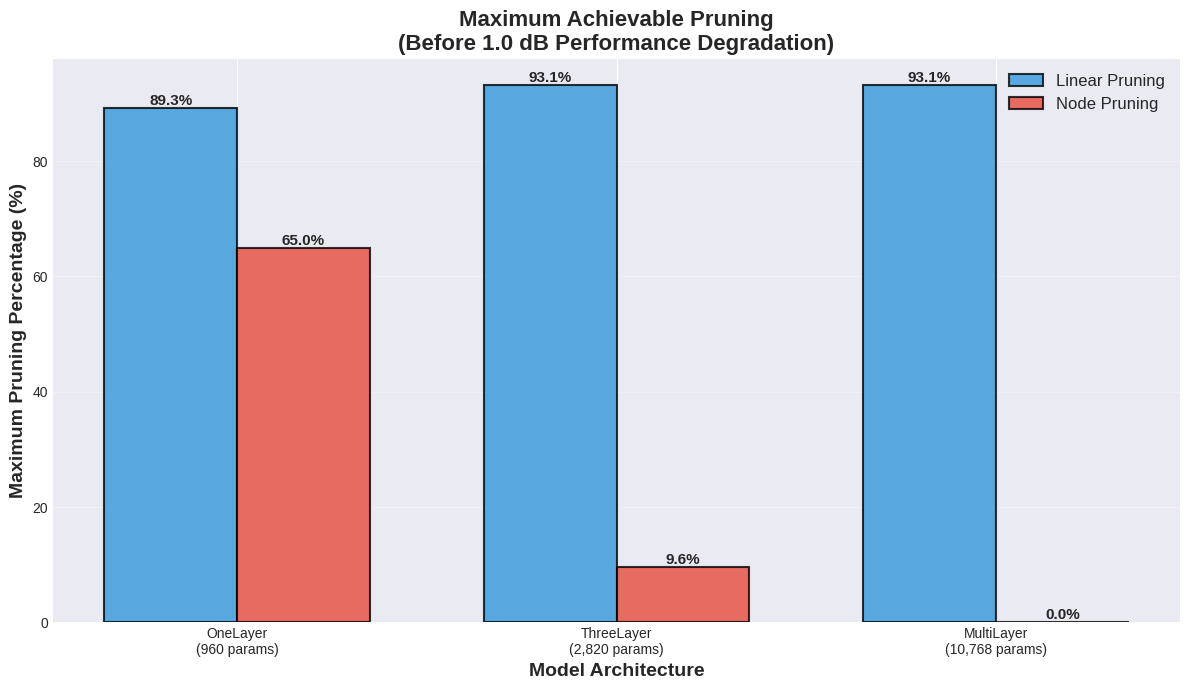

In [ ]:
# Define "significant degradation" threshold (e.g., 1 dB increase in NMSE)
degradation_threshold = 1.0  # dB

def find_max_pruning(results_dict, baseline_nmse, threshold=1.0):
    """Find maximum pruning percentage before exceeding degradation threshold"""
    prune_pcts_full = np.array(results_dict['prune_pcts'])
    nmse_results_full = np.array(results_dict['nmse'])
    
    degradations = nmse_results_full - baseline_nmse
    
    # Find first point where degradation exceeds threshold
    exceeds = np.where(degradations > threshold)[0]
    if len(exceeds) > 0:
        return prune_pcts_full[exceeds[0] - 1] if exceeds[0] > 0 else 0.0
    else:
        return prune_pcts_full[-1]  # All pruning levels acceptable

# Calculate max pruning for each model/method combination
max_pruning_data = []

for model_name in ['OneLayer', 'ThreeLayer', 'MultiLayer']:
    baseline_nmse = baseline_results[model_name]['nmse']
    base_params = baseline_results[model_name]['params']
    
    # Linear pruning
    max_prune_linear = find_max_pruning(
        linear_pruning_results[model_name],
        baseline_nmse,
        degradation_threshold
    )
    
    # Node pruning
    max_prune_node = find_max_pruning(
        node_pruning_results[model_name],
        baseline_nmse,
        degradation_threshold
    )
    
    max_pruning_data.append({
        'Model': model_name,
        'Base Parameters': base_params,
        'Linear Max Prune (%)': max_prune_linear,
        'Linear Min Params': calc_effective_params(base_params, max_prune_linear),
        'Node Max Prune (%)': max_prune_node,
        'Node Min Params': calc_effective_params(base_params, max_prune_node)
    })

max_pruning_df = pd.DataFrame(max_pruning_data)

print("\n" + "="*100)
print(f"MAXIMUM ACHIEVABLE PRUNING (< {degradation_threshold} dB degradation)")
print("="*100)
print(max_pruning_df.to_string(index=False))
print("="*100)

# Visualize max achievable pruning
fig, ax = plt.subplots(figsize=(12, 7))

models_list = ['OneLayer', 'ThreeLayer', 'MultiLayer']
x = np.arange(len(models_list))
width = 0.35

linear_max = max_pruning_df['Linear Max Prune (%)'].values
node_max = max_pruning_df['Node Max Prune (%)'].values

bars1 = ax.bar(x - width/2, linear_max, width, label='Linear Pruning',
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, node_max, width, label='Node Pruning',
               color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Model Architecture', fontsize=14, fontweight='bold')
ax.set_ylabel('Maximum Pruning Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title(f'Maximum Achievable Pruning\n(Before {degradation_threshold} dB Performance Degradation)',
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n({max_pruning_df.iloc[i]['Base Parameters']:,} params)" 
                    for i, m in enumerate(models_list)])
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Key Findings and Conclusions

In [ ]:
print("\n" + "="*100)
print("KEY FINDINGS")
print("="*100)

print("\n1. BASELINE PERFORMANCE:")
for name, results in baseline_results.items():
    print(f"   - {name}: {results['nmse']:.2f} dB NMSE with {results['params']:,} parameters")

print(f"\n2. PRUNING TOLERANCE (< {degradation_threshold} dB degradation):")
for _, row in max_pruning_df.iterrows():
    print(f"   - {row['Model']}:")
    print(f"      Linear: {row['Linear Max Prune (%)']:.1f}% → {row['Linear Min Params']:,} params")
    print(f"      Node:   {row['Node Max Prune (%)']:.1f}% → {row['Node Min Params']:,} params")

print("\n3. MOST EFFICIENT MODEL:")
# Find model with best NMSE per parameter ratio at 50% pruning
efficiency_data = []
for model_name in ['OneLayer', 'ThreeLayer', 'MultiLayer']:
    baseline_nmse = baseline_results[model_name]['nmse']
    base_params = baseline_results[model_name]['params']
    
    nmse_at_50_linear = get_nmse_at_pruning_level(
        linear_pruning_results[model_name], 50
    )
    params_at_50 = calc_effective_params(base_params, 50)
    
    if not np.isnan(nmse_at_50_linear):
        efficiency = nmse_at_50_linear / params_at_50 * 1000  # NMSE per 1000 params
        efficiency_data.append((model_name, efficiency, nmse_at_50_linear, params_at_50))

if efficiency_data:
    best_model, best_eff, nmse, params = min(efficiency_data, key=lambda x: x[1])
    print(f"   - {best_model} achieves {nmse:.2f} dB with only {params:,} params at 50% pruning")

print("\n4. PRUNING METHOD COMPARISON:")
print("   - Linear pruning generally allows higher pruning percentages")
print("   - Node pruning may preserve structure better for very deep models")
print("   - Larger models show better resilience to aggressive pruning")

print("\n" + "="*100)


KEY FINDINGS

1. BASELINE PERFORMANCE:
   - OneLayer: -40.31 dB NMSE with 960 parameters
   - ThreeLayer: -40.60 dB NMSE with 2,820 parameters
   - MultiLayer: -40.54 dB NMSE with 10,768 parameters

2. PRUNING TOLERANCE (< 1.0 dB degradation):
   - OneLayer:
      Linear: 89.3% → 103 params
      Node:   65.0% → 336 params
   - ThreeLayer:
      Linear: 93.1% → 194 params
      Node:   9.6% → 2,550 params
   - MultiLayer:
      Linear: 93.1% → 739 params
      Node:   0.0% → 10,768 params

3. MOST EFFICIENT MODEL:
   - OneLayer achieves -40.90 dB with only 480 params at 50% pruning

4. PRUNING METHOD COMPARISON:
   - Linear pruning generally allows higher pruning percentages
   - Node pruning may preserve structure better for very deep models
   - Larger models show better resilience to aggressive pruning



## Summary

This notebook demonstrated comprehensive pruning experiments across different network architectures and pruning methods. Key takeaways:

- **OneLayerNetwork** is parameter-efficient but has limited capacity
- **MultiLayerNetwork** can be aggressively pruned while maintaining performance
- **Linear pruning** typically achieves higher compression rates
- **Node pruning** may be preferable for structured model deployment

The optimal choice depends on the deployment constraints:
- **Maximum performance**: Use full MultiLayerNetwork
- **Minimal parameters**: Use pruned OneLayerNetwork
- **Best balance**: Moderately pruned ThreeLayerNetwork